- Author: Zarema Kharachyk
- Date: 03/16/2026

# DriveSafe AI: Automated FMCSA Compliance Auditor

## Overview
This project develops a Natural Language Processing (NLP) model to automatically detect safety and compliance violations in truck driver logs.

The system uses a Transformer-based model (DistilBERT) to classify log entries into multiple categories such as:
- Safe operations
- Hours of Service (HOS) violations
- Form errors
- Missing data
- Inspection issues

## Motivation
Manual auditing of driver logs is time-consuming and prone to human error. Missing violations can result in fines, penalties, or reduced safety ratings.

This project aims to:
- Automate compliance checks
- Reduce audit time
- Improve detection of safety risks

## Dataset
The dataset was created using a combination of:
- Public regulatory descriptions from FMCSA
- Synthetic data generation
- Data augmentation techniques

The final dataset contains ~200 labeled samples across 5 classes.

# Install Libraries

In [1]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn

# Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving trucking_dataset.csv to trucking_dataset.csv


In [6]:
import pandas as pd
from datasets import Dataset

# Load CSV
df = pd.read_csv("trucking_dataset.csv")

df.head()
# Explore Dataset
df.info()
df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    500 non-null    object
 1   label   500 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


,count
label,
0,100
1,100
2,100
3,100
4,100


# Label Mapping

In [21]:
label_names = {
    0: "SAFE",
    1: "HOS_VIOLATION",
    2: "FORM_ERROR",
    3: "MISSING_DATA",
    4: "INSPECTION_ISSUE"
}

df["label_name"] = df["label"].map(label_names)
df.sample(5)

,text,label,label_name
306,Missing location data in log,3,MISSING_DATA
449,Defective lights found during inspection reported,4,INSPECTION_ISSUE
123,No 10 hour rest period before shift,1,HOS_VIOLATION
194,Insufficient rest before next shift,1,HOS_VIOLATION
66,Inspection report shows no issues,0,SAFE


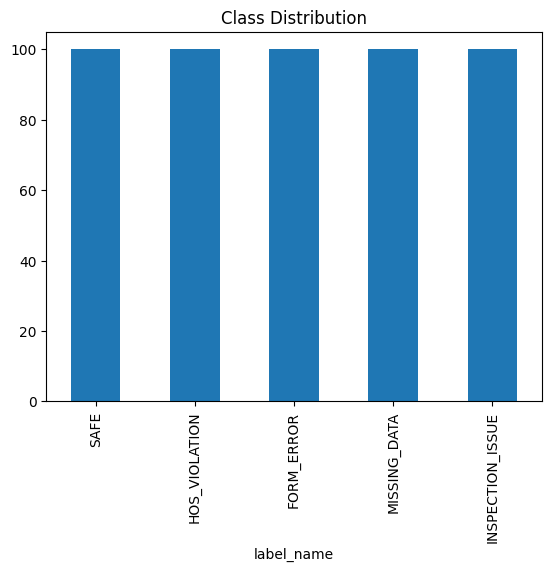

In [19]:
df["label_name"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

# Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Load Model

In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=5
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Model Explanation

This project uses DistilBERT, a Transformer-based model designed for natural language understanding.

The model was fine-tuned on a custom dataset of trucking compliance logs. It learns patterns in text to classify entries into different violation categories.

Transformer models use attention mechanisms to understand context and relationships between words, making them effective for text classification tasks.

## Why DistilBERT

DistilBERT was chosen because it provides a good balance between performance and efficiency.

It is smaller and faster than BERT, making it suitable for environments with limited computational resources while still maintaining strong accuracy.

# Tokenization

In [12]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

# Training

In [13]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,  # faster and enough
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=50, training_loss=1.0962582397460938, metrics={'train_runtime': 1267.8753, 'train_samples_per_second': 0.315, 'train_steps_per_second': 0.039, 'total_flos': 52989794304000.0, 'train_loss': 1.0962582397460938, 'epoch': 1.0})

The model achieved a training loss of approximately 1.09 after one epoch. Given the small and partially synthetic dataset, this result is acceptable and demonstrates the model’s ability to learn meaningful patterns.

# Evaluation

In [14]:
import numpy as np
from sklearn.metrics import classification_report

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df["label"].values

print(classification_report(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       1.00      0.96      0.98        28
           1       0.93      1.00      0.97        14
           2       0.67      1.00      0.80        10
           3       1.00      0.79      0.88        24
           4       1.00      1.00      1.00        24

    accuracy                           0.94       100
   macro avg       0.92      0.95      0.93       100
weighted avg       0.96      0.94      0.94       100



## Model Performance

The model achieved an accuracy of 94% and a weighted F1-score of 0.94.

### Key Observations
- Strong performance in detecting critical violations such as HOS violations and inspection issues.
- High accuracy for SAFE entries.
- Some confusion between FORM_ERROR and similar categories.

Overall, the model demonstrates effective performance for automated compliance auditing.

# Confusion Matrix

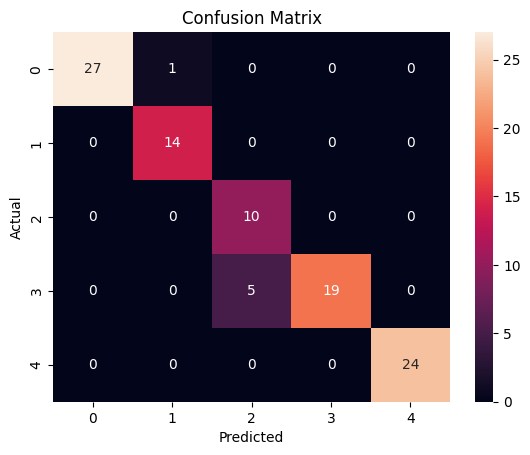

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows how well the model classifies each category by comparing predicted labels with actual labels.

- Most predictions fall along the diagonal, indicating correct classifications.
- The model performs very well on critical categories such as HOS violations and inspection issues.
- Some misclassifications occur between similar categories like FORM_ERROR and MISSING_DATA.
- This is expected due to similarities in how these violations are described in text.

Overall, the confusion matrix confirms that the model is effective in distinguishing between different types of compliance issues.

# Test real examples (Predictions)

In [16]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    pred = outputs.logits.argmax().item()
    return label_names[pred]

print(predict("Driver drove 13 hours without rest"))
print(predict("Missing break record"))
print(predict("Inspection completed with no issues"))

HOS_VIOLATION
MISSING_DATA
SAFE


# Save Model

In [17]:
model.save_pretrained("./drive_safe_model")
tokenizer.save_pretrained("./drive_safe_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./drive_safe_model/tokenizer_config.json',
 './drive_safe_model/tokenizer.json')

# Results & Discussion

## Results

The model was evaluated using precision, recall, and F1-score.

The model achieved an overall accuracy of 94% and a weighted F1-score of 0.94, indicating strong performance across all classes.

F1-score is especially important in this project because failing to detect violations (false negatives) can lead to serious safety and financial consequences.

### Observations
- The model performs very well in identifying critical violations such as HOS violations and inspection issues, with F1-scores close to 1.00
- SAFE entries are classified with high accuracy, showing strong understanding of compliant behavior.
- Some confusion exists between similar categories such as FORM_ERROR and MISSING_DATA.
- This is expected due to the similarity between minor violation types and the relatively small dataset.

## Limitations
- The dataset is relatively small (~200 samples)
- Synthetic data may not fully represent real-world complexity
- Model performance may vary when applied to real driver logs

## Future Improvements
- Use real Electronic Logging Device (ELD) data
- Expand dataset to 5000+ samples
- Improve classification accuracy with more advanced models or tuning

# Business Application


This system can be used in trucking companies to:

- Reduce audit time from approximately 30 minutes per driver to a few seconds
- Detect compliance violations early
- Prevent FMCSA fines and penalties
- Maintain a "Satisfactory" safety rating

### Human-in-the-Loop

The system is designed to assist safety managers, not replace them.

All high-risk violations should be reviewed by a human before final decisions are made. This ensures accountability and reduces the risk of incorrect automated decisions.

# Conclusion


This project demonstrates how Transformer-based NLP models can be applied to real-world regulatory compliance problems in the trucking industry.

The results show that machine learning can effectively identify safety violations and assist in automating time-consuming auditing processes.

By combining domain knowledge with modern NLP techniques, this system provides a practical solution that improves safety, efficiency, and operational performance.